# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [22]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
# TODO
# DATA SIZE
df.shape

(541909, 8)

In [3]:
# column names
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [4]:
df.columns.to_list()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [6]:
# data types
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

## A.2. Missing values & Duplicate data

In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
# TODO
df.duplicated

<bound method DataFrame.duplicated of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice

In [9]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Length: 541909, dtype: bool

## A.3. Invalid values

In [14]:
# TODO
#  Quantity <= 0 
invalid_quantity = df[df['Quantity'] <= 0]
print(invalid_quantity.head())

    InvoiceNo StockCode                       Description  Quantity  \
141   C536379         D                          Discount        -1   
154   C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235   C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236   C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237   C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   

            InvoiceDate  UnitPrice  CustomerID         Country  
141 2010-12-01 09:41:00      27.50     14527.0  United Kingdom  
154 2010-12-01 09:49:00       4.65     15311.0  United Kingdom  
235 2010-12-01 10:24:00       1.65     17548.0  United Kingdom  
236 2010-12-01 10:24:00       0.29     17548.0  United Kingdom  
237 2010-12-01 10:24:00       0.29     17548.0  United Kingdom  


In [15]:
# Description bị thiếu
invalid_description = df[df['Description'].isnull()]
print(invalid_description.head())

     InvoiceNo StockCode Description  Quantity         InvoiceDate  UnitPrice  \
622     536414     22139         NaN        56 2010-12-01 11:52:00        0.0   
1970    536545     21134         NaN         1 2010-12-01 14:32:00        0.0   
1971    536546     22145         NaN         1 2010-12-01 14:33:00        0.0   
1972    536547     37509         NaN         1 2010-12-01 14:33:00        0.0   
1987    536549    85226A         NaN         1 2010-12-01 14:34:00        0.0   

      CustomerID         Country  
622          NaN  United Kingdom  
1970         NaN  United Kingdom  
1971         NaN  United Kingdom  
1972         NaN  United Kingdom  
1987         NaN  United Kingdom  


## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [20]:
# TODO
sale_clean=df[(df['Quantity']>0) & (df['UnitPrice'] >0)].copy()
sale_clean['Sales']=sale_clean['Quantity']*sale_clean['UnitPrice']
sale_clean[['Quantity','UnitPrice','Sales']].head()


,Quantity,UnitPrice,Sales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [ ]:
# TODO
# Mean cho Sales
mean_sales = sale_clean['Sales'].mean()
print("Mean:", mean_sales)


Mean: 20.121871451639677
Median: 9.9
Mode: 15.0


In [26]:
# Median Sales
median_sales = sale_clean['Sales'].median()
print("Median:", median_sales)


Median: 9.9


In [27]:
# Mode Sales
mode_sales = sale_clean['Sales'].mode()[0]
print("Mode:", mode_sales)

Mode: 15.0


## Group 2 — Dispersion

In [44]:
# TODO
var_sales = sale_clean['Sales'].var()
std_sales = sale_clean['Sales'].std()
range_sales = sale_clean['Sales'].max() - sale_clean['Sales'].min()

print("Variance:", var_sales)
print("Standard Deviation:", std_sales)
print("Range:", range_sales)


Variance: 73092.76860366353
Standard Deviation: 270.35674321840673
Range: 168469.59900000002


## Group 3 — Location and Shape

In [ ]:
# TODO
quantiles = sale_clean['Sales'].quantile([0.25, 0.5, 0.75])
skewness = sale_clean['Sales'].skew()
kurtosis = sale_clean['Sales'].kurtosis()

print("Quantiles:\n", quantiles)
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)



Quantiles:
 0.25     3.75
0.50     9.90
0.75    17.70
Name: Sales, dtype: float64
Skewness: 506.7060119422723
Kurtosis: 297651.6610458157


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

In [38]:
# TODO
country_sales=sale_clean.groupby('Country')['Sales'].sum().sort_values(ascending=False)
print(country_sales.head(10),"\n")
country_sales_percent = country_sales / country_sales.sum() * 100

print("Country Sales Percent:\n", country_sales_percent)


Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: Sales, dtype: float64 

Country Sales Percent:
 Country
United Kingdom          84.611315
Netherlands              2.676055
EIRE                     2.657376
Germany                  2.145626
France                   1.966076
Australia                1.298635
Spain                    0.577284
Switzerland              0.535217
Belgium                  0.386215
Sweden                   0.359796
Japan                    0.350778
Norway                   0.339050
Portugal                 0.316379
Finland                  0.211369
Singapore                0.199493
Channel Islands          0.191723
Denmark                  0.177706
Italy                    0.163905
Hong Kong         

In [33]:
df


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

In [39]:
# TODO
product_sales = sale_clean.groupby('Description')['Sales'].sum().sort_values(ascending=False)
product_sales.head(10)



Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: Sales, dtype: float64

## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

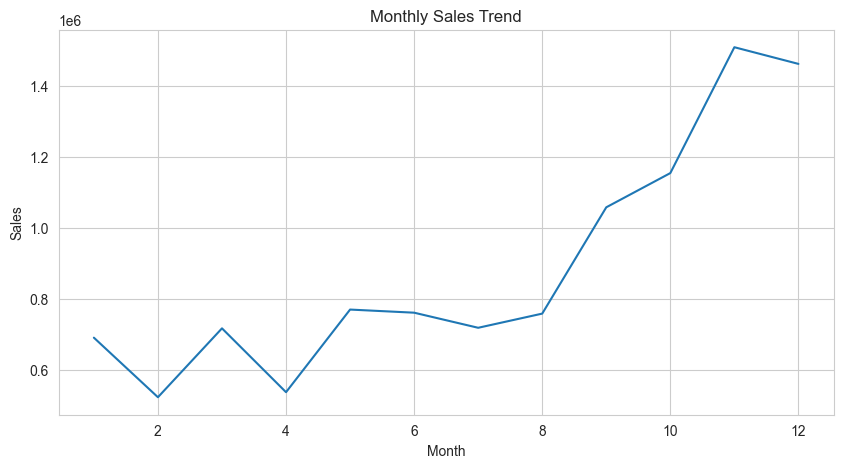

In [40]:
# TODO
sale_clean['Month'] = sale_clean['InvoiceDate'].dt.month
monthly_sales = sale_clean.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()


## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

In [41]:
# TODO
order_value = sale_clean.groupby('Country').apply(lambda g: g['Sales'].sum() / g['InvoiceNo'].nunique())
order_value.sort_values(ascending=False).head(10)


C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_20812\3860155953.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  order_value = sale_clean.groupby('Country').apply(lambda g: g['Sales'].sum() / g['InvoiceNo'].nunique())


Country
Singapore      3039.898571
Netherlands    3036.663191
Australia      2430.198421
Japan          1969.282632
Lebanon        1693.880000
Hong Kong      1426.527273
Brazil         1143.600000
Sweden         1066.064722
Switzerland    1057.220370
Denmark        1053.074444
dtype: float64

## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

In [42]:
# TODO
returns = df[df['Quantity'] < 0].groupby('Country')['InvoiceNo'].nunique()
total_orders = df.groupby('Country')['InvoiceNo'].nunique()

return_rate = (returns / total_orders * 100).fillna(0).sort_values(ascending=False)
return_rate.head(10)


Country
Czech Republic    60.000000
Malta             50.000000
Saudi Arabia      50.000000
Japan             32.142857
Italy             30.909091
Singapore         30.000000
USA               28.571429
Switzerland       27.027027
Hong Kong         26.666667
Bahrain           25.000000
Name: InvoiceNo, dtype: float64

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

*(Viết insight của bạn vào đây...)*
-Doanh thu tập trung chủ yếu ở United Kingdom, chiếm phần lớn tổng doanh thu.
-Một số sản phẩm phổ biến như “WHITE HANGING HEART T-LIGHT HOLDER” đóng góp doanh thu lớn.
-Doanh số có tính mùa vụ rõ rệt, tăng mạnh vào cuối năm (tháng 11–12).
-Average Order Value khác biệt đáng kể giữa các quốc gia, UK có giá trị đơn hàng trung bình cao hơn nhiều nước khác.
-Tỷ lệ trả hàng/hủy cao nhất cũng tập trung ở UK, phản ánh khối lượng giao dịch lớn và chính sách trả hàng linh hoạt.